In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


import matplotlib.pyplot as plt
import numpy as np
import os
import random


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

dataset_path = "/content/drive/MyDrive/Fruits_data"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=basic_transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Banana_Class_A', 'Banana_Class_B', 'Banana_Defect', 'Guava_Class_A', 'Guava_Class_B', 'Guava_Defect']
Total Images: 1748


In [ ]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training Images :", len(train_ds))
print("Validation Images:", len(val_ds))
print("Testing Images   :", len(test_ds))

Training Images : 1223
Validation Images: 262
Testing Images   : 263


In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

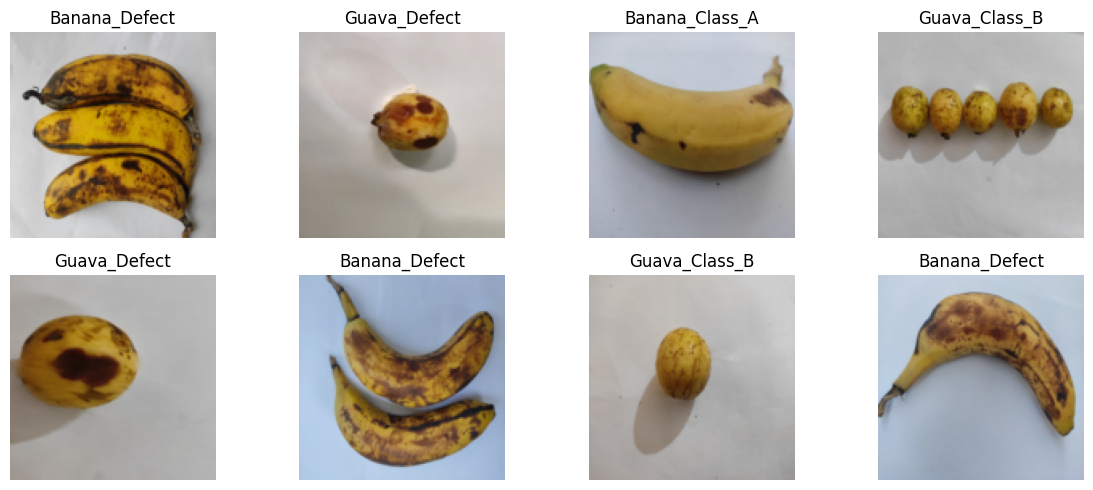

In [ ]:
images, labels = next(iter(train_loader))

class_names = dataset.classes

plt.figure(figsize=(12,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i].permute(1,2,0))

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:

#   CNN


class SimpleCNN(nn.Module):

    def __init__(self, p_dropout=0.0):

        super().__init__()

        # Feature Extractor

        self.conv1 = nn.Conv2d(3,16,kernel_size=3,padding=1)

        self.conv2 = nn.Conv2d(16,32,kernel_size=3,padding=1)

        self.conv3 = nn.Conv2d(32,64,kernel_size=3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        # Classification Head

        self.dropout = nn.Dropout(p_dropout)

        self.fc1 = nn.Linear(64*16*16,128)

        self.fc2 = nn.Linear(128,6)     # 6 classes

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = self.pool(F.relu(self.conv3(x)))

        x = torch.flatten(x,1)

        x = self.dropout(x)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [ ]:

# Model Creation


model = SimpleCNN(p_dropout=0.0).to(device)

print(model)

n_params = sum(p.numel() for p in model.parameters())

print(f"\nTotal Trainable Parameters : {n_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

Total Trainable Parameters : 2,121,638


In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss":[],
        "val_loss":[],
        "train_acc":[],
        "val_acc":[]
    }

    for epoch in range(epochs):

        # TRAIN

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()*images.size(0)

            _,predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

        train_loss = running_loss/total

        train_acc = correct/total

        # VALIDATION

        model.eval()

        running_loss = 0

        correct = 0

        total = 0

        with torch.no_grad():

            for images,labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs,labels)

                running_loss += loss.item()*images.size(0)

                _,predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted==labels).sum().item()

        val_loss = running_loss/total

        val_acc = correct/total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
      f"Train Loss: {train_loss:.4f} | "
      f"Train Acc: {train_acc*100:.2f}% | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val Acc: {val_acc*100:.2f}%")

    return history

In [ ]:
# training round 1

history_plain = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15
)

Epoch  1/15 | Train Loss: 1.4657 | Train Acc: 36.63% | Val Loss: 1.3771 | Val Acc: 41.22%
Epoch  2/15 | Train Loss: 1.0428 | Train Acc: 58.54% | Val Loss: 0.7899 | Val Acc: 73.66%
Epoch  3/15 | Train Loss: 0.6687 | Train Acc: 74.82% | Val Loss: 0.6033 | Val Acc: 76.72%
Epoch  4/15 | Train Loss: 0.4914 | Train Acc: 80.78% | Val Loss: 0.5541 | Val Acc: 77.86%
Epoch  5/15 | Train Loss: 0.4128 | Train Acc: 84.71% | Val Loss: 0.4896 | Val Acc: 79.39%
Epoch  6/15 | Train Loss: 0.3830 | Train Acc: 85.04% | Val Loss: 0.4584 | Val Acc: 81.68%
Epoch  7/15 | Train Loss: 0.3235 | Train Acc: 87.82% | Val Loss: 0.5180 | Val Acc: 79.77%
Epoch  8/15 | Train Loss: 0.2782 | Train Acc: 89.45% | Val Loss: 0.4867 | Val Acc: 82.44%
Epoch  9/15 | Train Loss: 0.2810 | Train Acc: 89.29% | Val Loss: 0.5289 | Val Acc: 80.92%
Epoch 10/15 | Train Loss: 0.2116 | Train Acc: 91.91% | Val Loss: 0.4841 | Val Acc: 83.59%
Epoch 11/15 | Train Loss: 0.2341 | Train Acc: 90.84% | Val Loss: 0.7665 | Val Acc: 74.05%
Epoch 12/1

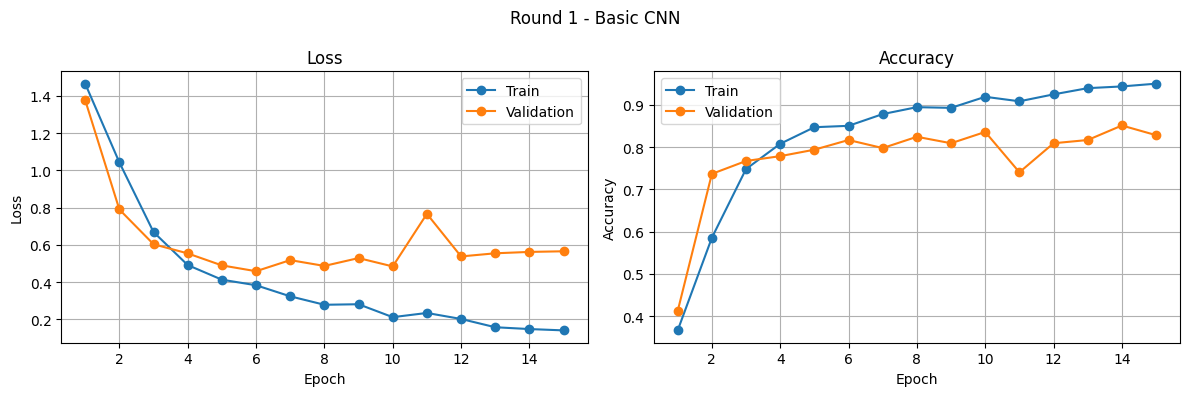

In [ ]:
def plot_history(history,title=""):

    epochs = range(1,len(history["train_loss"])+1)

    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

    ax1.plot(
        epochs,
        history["train_loss"],
        "o-",
        label="Train"
    )

    ax1.plot(
        epochs,
        history["val_loss"],
        "o-",
        label="Validation"
    )

    ax1.set_title("Loss")

    ax1.set_xlabel("Epoch")

    ax1.set_ylabel("Loss")

    ax1.legend()

    ax1.grid(True)

    ax2.plot(
        epochs,
        history["train_acc"],
        "o-",
        label="Train"
    )

    ax2.plot(
        epochs,
        history["val_acc"],
        "o-",
        label="Validation"
    )

    ax2.set_title("Accuracy")

    ax2.set_xlabel("Epoch")

    ax2.set_ylabel("Accuracy")

    ax2.legend()

    ax2.grid(True)

    fig.suptitle(title)

    plt.tight_layout()

    plt.show()

plot_history(history_plain,"Round 1 - Basic CNN")

In [ ]:
#overfitting spotting

print(f"Best Training Accuracy   : {max(history_plain['train_acc'])*100:.2f}%")
print(f"Best Validation Accuracy : {max(history_plain['val_acc'])*100:.2f}%")

if history_plain["train_acc"][-1] - history_plain["val_acc"][-1] > 0.10:
    print("\nThe model is likely overfitting.")
else:
    print("\nNo significant overfitting detected.")

Best Training Accuracy   : 95.01%
Best Validation Accuracy : 85.11%

The model is likely overfitting.


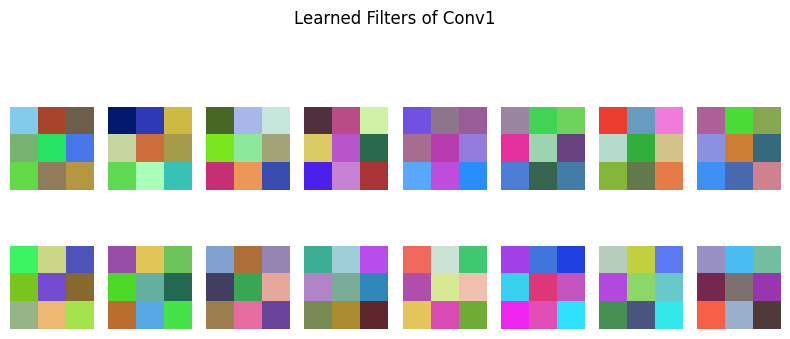

In [ ]:
weights = model.conv1.weight.data.clone().cpu()

w_min = weights.min()
w_max = weights.max()

weights = (weights - w_min) / (w_max - w_min + 1e-8)

plt.figure(figsize=(8,4))

for i in range(16):

    plt.subplot(2,8,i+1)

    plt.imshow(weights[i].permute(1,2,0))

    plt.axis("off")

plt.suptitle("Learned Filters of Conv1")

plt.tight_layout()

plt.show()

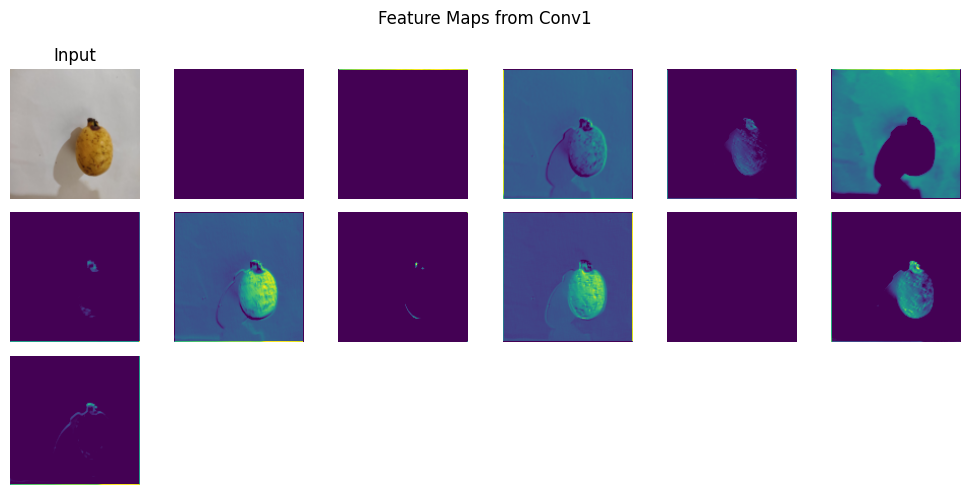

In [ ]:
img, label = val_ds[0]

img_batch = img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    feature_maps = F.relu(model.conv1(img_batch)).cpu()[0]

plt.figure(figsize=(10,5))

plt.subplot(3,6,1)

plt.imshow(img.permute(1,2,0))

plt.title("Input")

plt.axis("off")

for i in range(12):

    plt.subplot(3,6,i+2)

    plt.imshow(feature_maps[i], cmap="viridis")

    plt.axis("off")

plt.suptitle("Feature Maps from Conv1")

plt.tight_layout()

plt.show()

Output Shape: (64, 32, 32)


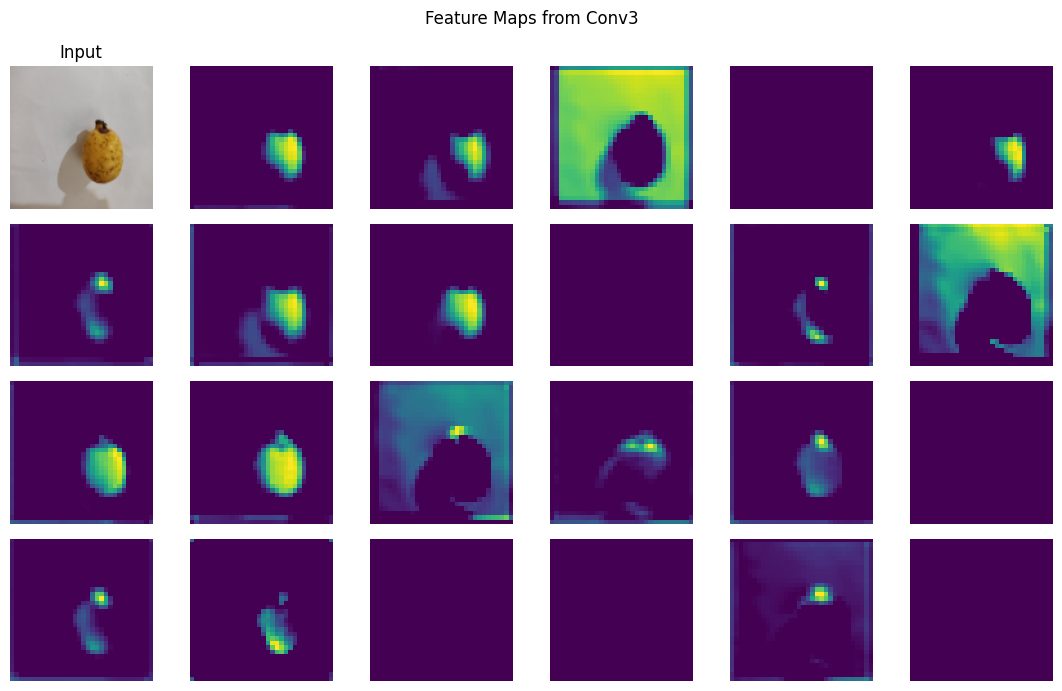

In [ ]:
img, label = val_ds[0]

x = img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    x = model.pool(F.relu(model.conv1(x)))

    x = model.pool(F.relu(model.conv2(x)))

    last_maps = F.relu(model.conv3(x)).cpu()[0]

print("Output Shape:", tuple(last_maps.shape))

plt.figure(figsize=(11,7))

plt.subplot(4,6,1)

plt.imshow(img.permute(1,2,0))

plt.title("Input")

plt.axis("off")

for i in range(23):

    plt.subplot(4,6,i+2)

    plt.imshow(last_maps[i], cmap="viridis")

    plt.axis("off")

plt.suptitle("Feature Maps from Conv3")

plt.tight_layout()

plt.show()

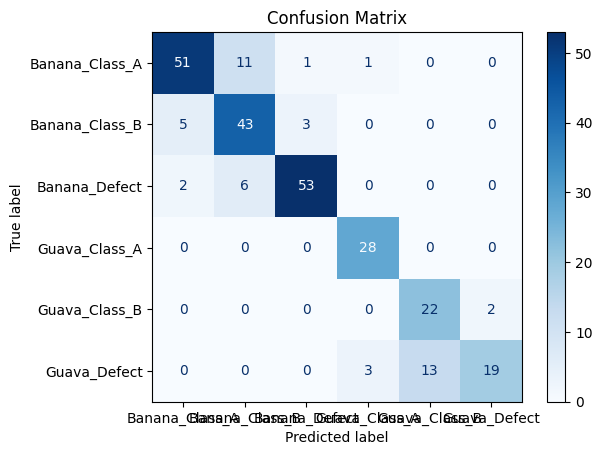

In [ ]:
def get_predictions(model, loader):

    model.eval()

    predictions = []

    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            predictions.extend(predicted.cpu().numpy())

            targets.extend(labels.numpy())

    return predictions, targets


y_pred, y_true = get_predictions(model, test_loader)

class_names = dataset.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                precision    recall  f1-score   support

Banana_Class_A       0.88      0.80      0.84        64
Banana_Class_B       0.72      0.84      0.77        51
 Banana_Defect       0.93      0.87      0.90        61
 Guava_Class_A       0.88      1.00      0.93        28
 Guava_Class_B       0.63      0.92      0.75        24
  Guava_Defect       0.90      0.54      0.68        35

      accuracy                           0.82       263
     macro avg       0.82      0.83      0.81       263
  weighted avg       0.84      0.82      0.82       263



In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor()

])

val_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor()

])

dataset_aug = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

dataset_clean = datasets.ImageFolder(
    root=dataset_path,
    transform=val_transform
)

In [ ]:
train_ds_aug, val_ds_clean, test_ds_clean = random_split(

    dataset_aug,

    [train_size, val_size, test_size],

    generator=torch.Generator().manual_seed(42)

)

train_loader_aug = DataLoader(
    train_ds_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_clean = DataLoader(
    val_ds_clean,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_clean = DataLoader(
    test_ds_clean,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Augmented Dataset Ready")

Augmented Dataset Ready


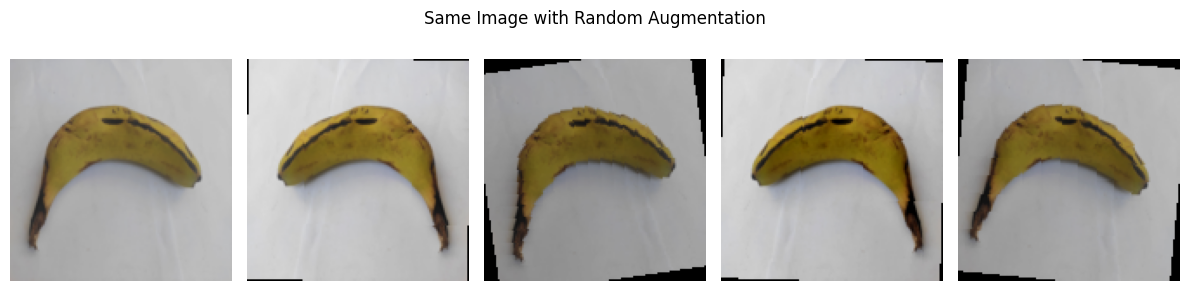

In [ ]:
plt.figure(figsize=(12,3))

for i in range(5):

    img,_ = train_ds_aug[0]

    plt.subplot(1,5,i+1)

    plt.imshow(img.permute(1,2,0))

    plt.axis("off")

plt.suptitle("Same Image with Random Augmentation")

plt.tight_layout()

plt.show()

In [ ]:

#  Train Round 2


model_aug = SimpleCNN(
    p_dropout=0.5
).to(device)

history_aug = train_model(

    model_aug,

    train_loader_aug,

    val_loader_clean,

    epochs=30

)

Epoch  1/30 | Train Loss: 1.5651 | Train Acc: 28.54% | Val Loss: 1.3422 | Val Acc: 47.33%
Epoch  2/30 | Train Loss: 1.1998 | Train Acc: 49.63% | Val Loss: 0.9878 | Val Acc: 61.83%
Epoch  3/30 | Train Loss: 0.9133 | Train Acc: 62.88% | Val Loss: 0.8159 | Val Acc: 69.85%
Epoch  4/30 | Train Loss: 0.7517 | Train Acc: 69.91% | Val Loss: 0.7688 | Val Acc: 66.79%
Epoch  5/30 | Train Loss: 0.7538 | Train Acc: 69.26% | Val Loss: 0.6859 | Val Acc: 74.05%
Epoch  6/30 | Train Loss: 0.7015 | Train Acc: 73.18% | Val Loss: 0.7129 | Val Acc: 68.70%
Epoch  7/30 | Train Loss: 0.6358 | Train Acc: 73.43% | Val Loss: 0.5843 | Val Acc: 77.48%
Epoch  8/30 | Train Loss: 0.5774 | Train Acc: 76.94% | Val Loss: 0.5047 | Val Acc: 82.06%
Epoch  9/30 | Train Loss: 0.5591 | Train Acc: 77.60% | Val Loss: 0.5810 | Val Acc: 78.63%
Epoch 10/30 | Train Loss: 0.5181 | Train Acc: 78.82% | Val Loss: 0.4824 | Val Acc: 80.53%
Epoch 11/30 | Train Loss: 0.4993 | Train Acc: 79.48% | Val Loss: 0.8096 | Val Acc: 65.27%
Epoch 12/3

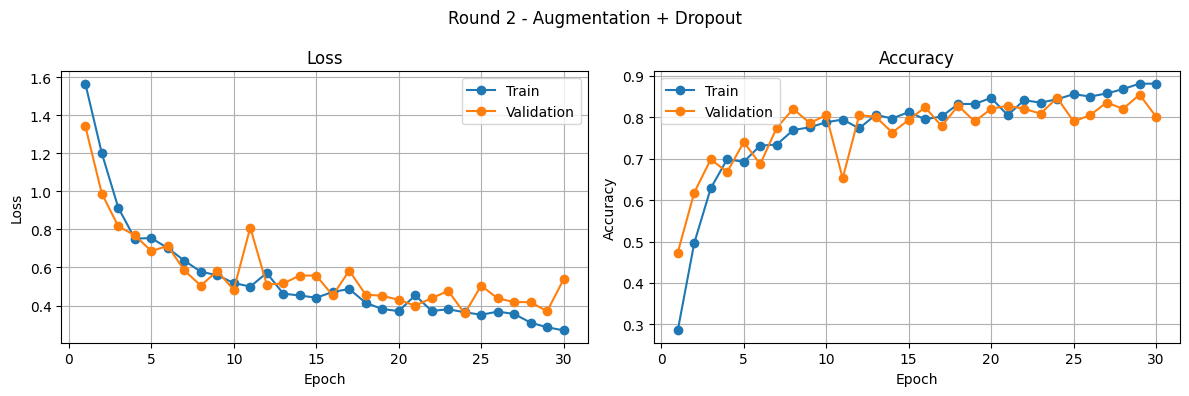

In [ ]:
plot_history(
    history_aug,
    "Round 2 - Augmentation + Dropout"
)

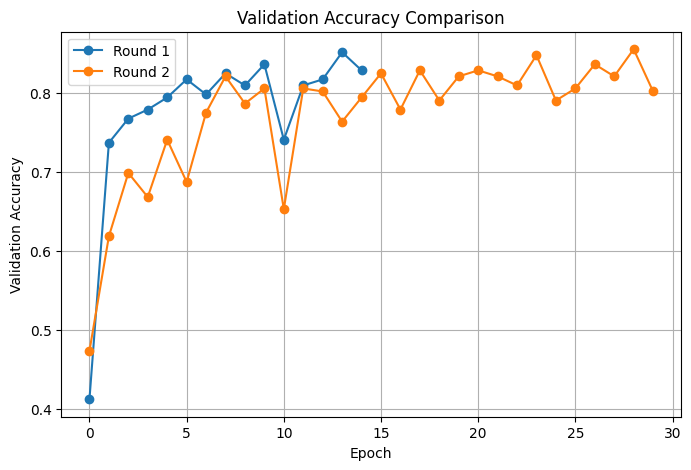

Best Validation Accuracy (Round 1): 85.11%
Best Validation Accuracy (Round 2): 85.50%


In [ ]:

# Comparing Two Rounds


plt.figure(figsize=(8,5))

plt.plot(
    history_plain["val_acc"],
    "o-",
    label="Round 1"
)

plt.plot(
    history_aug["val_acc"],
    "o-",
    label="Round 2"
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.grid(True)

plt.legend()

plt.show()

print(f"Best Validation Accuracy (Round 1): {max(history_plain['val_acc'])*100:.2f}%")

print(f"Best Validation Accuracy (Round 2): {max(history_aug['val_acc'])*100:.2f}%")

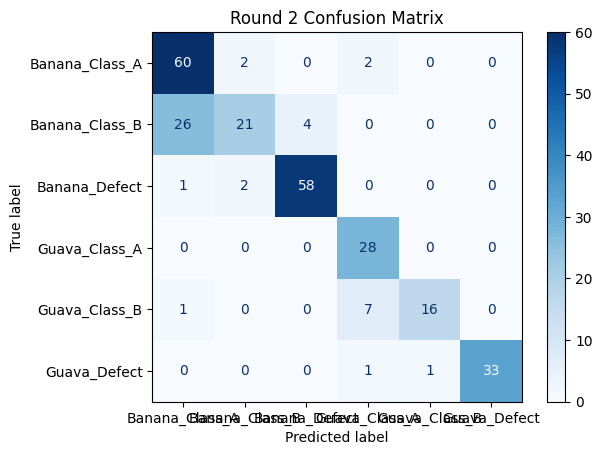

In [ ]:
y_pred, y_true = get_predictions(
    model_aug,
    test_loader_clean
)

class_names = dataset.classes

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Round 2 Confusion Matrix")

plt.show()

In [ ]:

# Classification Report


print(classification_report(

    y_true,

    y_pred,

    target_names=class_names

))

                precision    recall  f1-score   support

Banana_Class_A       0.68      0.94      0.79        64
Banana_Class_B       0.84      0.41      0.55        51
 Banana_Defect       0.94      0.95      0.94        61
 Guava_Class_A       0.74      1.00      0.85        28
 Guava_Class_B       0.94      0.67      0.78        24
  Guava_Defect       1.00      0.94      0.97        35

      accuracy                           0.82       263
     macro avg       0.86      0.82      0.81       263
  weighted avg       0.84      0.82      0.81       263

